In [1]:
import os
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import albumentations as A

d:\Education\Cellula\EyeDisease\EyeDisease\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DATA_DIR = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data")
IMAGES_DIR = DATA_DIR / "images"
SPLIT_DIR = DATA_DIR / "dataset_splits_v2"
AUG_DIR = DATA_DIR / "images_augmented_v2"
meta =pd.read_csv(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\metadata.csv")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CLASSES = [
    "Normal",
    "Diabetic Retinopathy",
    "Glaucoma",
    "Cataract",
    "AMD",
    "Hypertension",
    "Myopia",
    "Others",
]

TARGETS = {
    "Normal": 3000,
    "Diabetic Retinopathy": 2800,
    "Others": 1500,
    "Glaucoma": 1500,
    "Cataract": 1000,
    "Myopia": 1000,
    "AMD": 1000,
    "Hypertension": 500,
}

In [5]:
def resolve_image_path(filename):
    p = IMAGES_DIR / filename
    if p.exists():
        return p
    matches = list(IMAGES_DIR.rglob(filename))
    if len(matches) == 1:
        return matches[0]
    if len(matches) == 0:
        raise FileNotFoundError(f"Image not found: {filename}")
    raise FileExistsError(f"Multiple matches for {filename}: {matches[:5]}")

In [7]:
# ============================================================
# Cell 2: Stratified split 70/15/15 قبل أي augmentation
# ============================================================
train_df, temp_df = train_test_split(
    meta,
    test_size=0.30,
    stratify=meta["unified_label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["unified_label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 8287
Val size: 1776
Test size: 1776


In [8]:
for d in [SPLIT_DIR / "train_original", SPLIT_DIR / "val", SPLIT_DIR / "test"]:
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

def copy_split(df, split_name):
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Copying {split_name}"):
        src = resolve_image_path(row["filename"])
        dst_dir = SPLIT_DIR / split_name / row["unified_label"]
        dst_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst_dir / src.name)

copy_split(train_df, "train_original")
copy_split(val_df, "val")
copy_split(test_df, "test")

Copying test: 100%|██████████| 1776/1776 [00:02<00:00, 677.52it/s]


In [10]:
train_counts = train_df["unified_label"].value_counts().reindex(CLASSES)

imbalance_df = pd.DataFrame({
    "train_count": train_counts,
    "target": pd.Series(TARGETS),
})

imbalance_df["action"] = np.where(
    imbalance_df["train_count"] > imbalance_df["target"], "undersample",
    np.where(imbalance_df["train_count"] < imbalance_df["target"], "augment", "keep")
)

imbalance_df["difference"] = imbalance_df["target"] - imbalance_df["train_count"]

display(imbalance_df)

,train_count,target,action,difference
AMD,192,1000,augment,808
Cataract,238,1000,augment,762
Diabetic Retinopathy,2879,2800,undersample,-79
Glaucoma,651,1500,augment,849
Hypertension,62,500,augment,438
Myopia,206,1000,augment,794
Normal,3288,3000,undersample,-288
Others,771,1500,augment,729


In [11]:
try:
    gauss = A.GaussNoise(std_range=(0.05, 0.25), p=0.2)
except TypeError:
    try:
        gauss = A.GaussNoise(var_limit=(5.0, 25.0), p=0.2)
    except TypeError:
        gauss = A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.2)

train_aug = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=0.7
    ),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.5
    ),
    A.Blur(blur_limit=3, p=0.2),
    gauss,
])

def augment_and_save(src_path, dst_path, transform, max_tries=5):
    for _ in range(max_tries):
        try:
            img = Image.open(src_path).convert("RGB")
            arr = np.array(img)
            aug = transform(image=arr)["image"]
            Image.fromarray(aug).save(dst_path, quality=95)
            return True
        except Exception:
            continue
    return False

d:\Education\Cellula\EyeDisease\EyeDisease\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_23732\3292600501.py:10: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(


In [12]:
FINAL_TRAIN = SPLIT_DIR / "train"

if FINAL_TRAIN.exists():
    shutil.rmtree(FINAL_TRAIN)
FINAL_TRAIN.mkdir(parents=True, exist_ok=True)

if AUG_DIR.exists():
    shutil.rmtree(AUG_DIR)
AUG_DIR.mkdir(parents=True, exist_ok=True)

for cls in CLASSES:
    src_dir = SPLIT_DIR / "train_original" / cls
    dst_dir = FINAL_TRAIN / cls
    aug_cls_dir = AUG_DIR / cls

    dst_dir.mkdir(parents=True, exist_ok=True)
    aug_cls_dir.mkdir(parents=True, exist_ok=True)

    files = sorted([p for p in src_dir.glob("*") if p.is_file()])
    current = len(files)
    target = TARGETS[cls]

    if current == 0:
        print(f"[WARN] No files for {cls}")
        continue

    if current > target:
        selected = random.sample(files, target)
        for p in selected:
            shutil.copy2(p, dst_dir / p.name)
        print(f"{cls}: undersampled {current} -> {target}")

    elif current == target:
        for p in files:
            shutil.copy2(p, dst_dir / p.name)
        print(f"{cls}: kept {target}")

    else:
        for p in files:
            shutil.copy2(p, dst_dir / p.name)

        needed = target - current
        generated = 0
        attempts = 0
        max_attempts = max(needed * 10, 100)

        while generated < needed and attempts < max_attempts:
            src = random.choice(files)
            aug_name = f"aug_{generated:05d}_{src.stem}.jpg"
            aug_path = aug_cls_dir / aug_name

            if augment_and_save(src, aug_path, train_aug):
                shutil.copy2(aug_path, dst_dir / aug_name)
                generated += 1

            attempts += 1

        print(f"{cls}: kept {current}, generated {generated}, total {current + generated} / target {target}")

        if generated < needed:
            print(f"[WARN] {cls}: only generated {generated}/{needed}")

Normal: undersampled 3288 -> 3000
Diabetic Retinopathy: undersampled 2879 -> 2800
Glaucoma: kept 651, generated 849, total 1500 / target 1500
Cataract: kept 238, generated 762, total 1000 / target 1000
AMD: kept 192, generated 808, total 1000 / target 1000
Hypertension: kept 62, generated 438, total 500 / target 500
Myopia: kept 206, generated 794, total 1000 / target 1000
Others: kept 771, generated 729, total 1500 / target 1500


split,test,train,val
class,,,
Normal,705,3000,705
Diabetic Retinopathy,617,2800,617
Glaucoma,140,1500,139
Cataract,51,1000,51
AMD,41,1000,41
Hypertension,13,500,13
Myopia,44,1000,44
Others,165,1500,166


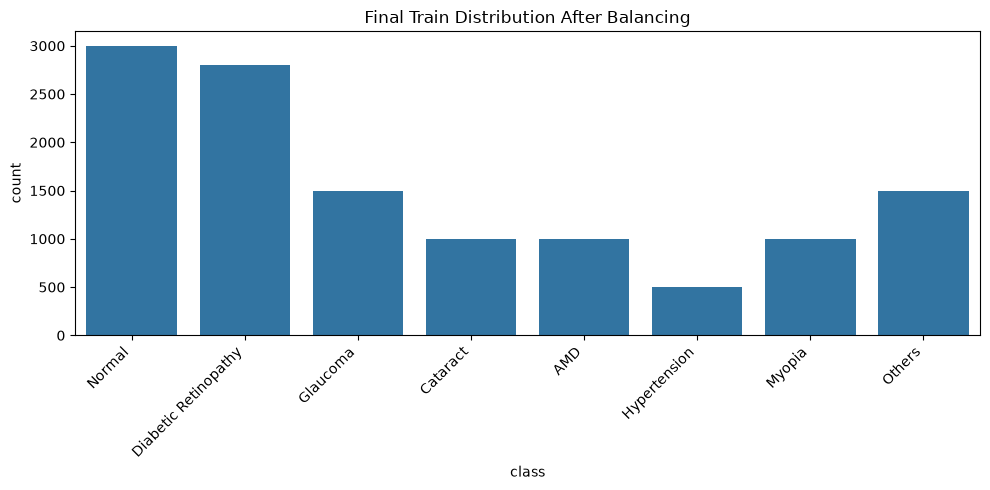

val augmented files: 0
test augmented files: 0


In [13]:
def count_split(split_name):
    rows = []
    for cls in CLASSES:
        d = SPLIT_DIR / split_name / cls
        n = len([p for p in d.glob("*") if p.is_file()]) if d.exists() else 0
        rows.append({"split": split_name, "class": cls, "count": n})
    return pd.DataFrame(rows)

final_counts = pd.concat([
    count_split("train"),
    count_split("val"),
    count_split("test"),
], ignore_index=True)

display(
    final_counts
    .pivot(index="class", columns="split", values="count")
    .reindex(CLASSES)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_counts[final_counts["split"] == "train"], x="class", y="count")
plt.xticks(rotation=45, ha="right")
plt.title("Final Train Distribution After Balancing")
plt.tight_layout()
plt.show()

# تأكيد أن val/test لا يحتويان على صور augmented
for split in ["val", "test"]:
    aug_files = list((SPLIT_DIR / split).rglob("aug_*"))
    print(f"{split} augmented files: {len(aug_files)}")